# Deep Operator Network (DeepONet) for the 1D Poisson Equation

This notebook implements a **physics-informed Deep Operator Network (DeepONet)** to learn the solution operator of the 1D Poisson equation with Dirichlet boundary conditions:

$$-u''(x) = f(x), \quad x \in [0,1], \quad u(0) = u(1) = 0$$

The network learns to map a **forcing function** $f$ to the corresponding **solution** $u$, trained purely from the PDE residual and boundary conditions — **no labelled solution data required**.

---

## 1. Imports

Standard scientific Python stack: `torch` for model and autograd, `numpy` for numerics, `matplotlib` for visualisation.

In [1]:
import math
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

## 2. Function Space — Random Polynomial Forcing Functions

We define the class of input functions $f$ used during training: random degree-3 polynomials

$$f(x) = a_0 + a_1 x + a_2 x^2 + a_3 x^3, \quad a_i \sim \mathcal{N}(0, \sigma^2)$$

- **`sample_polynomial_coeffs`** — samples a batch of random coefficient vectors from a Gaussian distribution.
- **`eval_polynomial`** — evaluates the batched polynomial at a set of query points $x$ using vectorised power-sum computation.

In [17]:
def sample_polynomial_coeffs(batch_size:int, degree:int = 3, scale:float = 1.0):
    return scale * torch.randn(batch_size, degree + 1, device="cuda")

def eval_polynomial(coeffs:torch.Tensor, x:torch.Tensor):

    B,D1 = coeffs.shape
    D = D1 - 1

    if x.dim() == 2:
        x = x.unsqueeze(0).repeat(B,1,1)

    powers = torch.cat([x**k for k in range(D+1)], dim=-1)
    c = coeffs.unsqueeze(1)
    f = (powers * c).sum(dim=-1,keepdim=True)
    return f     

## 3. Model Architecture — DeepONet

### `MLP`
A generic multi-layer perceptron with configurable hidden layers and Tanh activations.

### `DeepONet`
Implements the standard DeepONet architecture:

| Sub-network | Input | Role |
|---|---|---|
| **Branch** | $f$ sampled at $m$ sensor points | Encodes the input function into a $p$-dim embedding |
| **Trunk** | Query coordinate $x \in [0,1]$ | Encodes the output location into a $p$-dim embedding |

**Output**: dot product of branch and trunk embeddings, multiplied by $x(1-x)$ to **hard-enforce** the Dirichlet boundary conditions $u(0) = u(1) = 0$.

In [18]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden, out_dim, act=nn.Tanh):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev,h),act()]
            prev = h
        layers += [nn.Linear(prev,out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self,x):
        return self.net(x)


class DeepONet(nn.Module):
    def __init__(self, m_sensors:int, p:int = 32):
        super().__init__()
        self.branch = MLP(in_dim=m_sensors, hidden=[64,64], out_dim=p, act=nn.Tanh)
        self.trunk = MLP(in_dim=1, hidden=[64,64], out_dim=p, act=nn.Tanh)

    def forward(self,f_sensors,x):
        B = f_sensors.shape[0]
        if x.dim() == 2:
            x_in = x.unsqueeze(0).repeat(B,1,1)
        else:
            x_in = x

        b = self.branch(f_sensors)
        t = self.trunk(x_in)

        u = (t * b.unsqueeze(1)).sum(dim=-1,keepdim=True)

        u = x_in * (1 - x_in) * u

        return u


## 4. Second Derivative via Automatic Differentiation

`second_derivative(u, x)` computes $u''(x)$ by applying `torch.autograd.grad` twice with `create_graph=True`, so that gradients of the PDE residual can flow back through the network during training.

In [19]:
def second_derivative(u,x):

    du_dx = torch.autograd.grad(
        outputs=u,
        inputs=x,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True
    )[0]

    d2u_dx2 = torch.autograd.grad(
        outputs=du_dx,
        inputs=x,
        grad_outputs=torch.ones_like(du_dx),
        create_graph=True,
        retain_graph=True,

    )[0]
    return d2u_dx2

## 5. Hyperparameters and Setup

| Parameter | Value | Description |
|---|---|---|
| `m` | 10 | Number of sensor points |
| `p` | 32 | Latent dimension (branch/trunk output size) |
| `N_domain` | 100 | Collocation points per training step |
| `batch_size` | 64 | Forcing functions per batch |
| `w_pde` | 1.0 | PDE residual loss weight |
| `w_bc` | 10.0 | Boundary condition loss weight |

Sensor and collocation points are fixed uniform grids on $[0,1]$. Optimiser: **Adam** with learning rate $10^{-3}$.

In [20]:
torch.manual_seed(0)
np.random.seed(0)

m = 10
p = 32
N_domain = 100
batch_size = 64

x_sensors = torch.linspace(0,1,m,device="cuda").view(-1,1)
x_domain = torch.linspace(0,1,N_domain,device="cuda").view(-1,1)

model = DeepONet(m_sensors=m,p=p).to("cuda")
optimizer = optim.Adam(model.parameters(),lr=1e-3)

w_pde = 1.0
w_bc = 10.0

## 6. Training Loop

Each `train_step` performs one gradient update:

1. Sample a batch of random polynomial forcing functions $f$.
2. Evaluate $f$ at the sensor locations (branch input).
3. Run a forward pass to predict $u(x)$ at the collocation points.
4. Compute the **PDE residual loss**: $\mathcal{L}_{\text{pde}} = \|{-u'' - f}\|^2$.
5. Compute the **boundary condition loss**: $\mathcal{L}_{\text{bc}} = u(0)^2 + u(1)^2$ (auxiliary; BCs are also hard-enforced via the $x(1-x)$ output mask).
6. Minimise the weighted sum: $\mathcal{L} = w_{\text{pde}}\,\mathcal{L}_{\text{pde}} + w_{\text{bc}}\,\mathcal{L}_{\text{bc}}$.

Training runs for **10,000 steps**, printing losses every 500 steps.

In [27]:
def train_step():
    model.train()
    optimizer.zero_grad()

    coeffs = sample_polynomial_coeffs(batch_size=batch_size,degree=3,scale=1.0)

    f_sensor_vals = eval_polynomial(coeffs,x_sensors).squeeze(-1)

    f_domain = eval_polynomial(coeffs,x_domain)

    x_in = x_domain.unsqueeze(0).repeat(batch_size,1,1).clone().detach().requires_grad_(True)

    u = model(f_sensor_vals,x_in)

    u_xx = second_derivative(u,x_in)
    res = -u_xx - f_domain
    loss_pde = (res**2).mean()

    x0 = torch.zeros(batch_size,1 ,1, device="cuda", requires_grad=False)
    x1 = torch.ones(batch_size,1,1,device="cuda",requires_grad=False)
    u0 = model(f_sensor_vals,x0)
    u1 = model(f_sensor_vals,x1)
    loss_bc = (u0**2).mean() + (u1**2).mean()

    loss = w_pde * loss_pde + w_bc * loss_bc
    loss.backward()
    optimizer.step()

    return loss.item(), loss_pde.item(), loss_bc.item()


    


### Training — run

In [28]:
steps = 10000
print_every = 500

for step in range(1, steps+1):
    loss,lpde,lbc = train_step()
    if step%print_every == 0 or step == 1:
        print(f"Step {step:5d} | loss = {loss:.3e} | pde={lpde:.3e} | bc={lbc:.3e}")

Step     1 | loss = 2.188e+00 | pde=2.188e+00 | bc=0.000e+00
Step   500 | loss = 2.346e-03 | pde=2.346e-03 | bc=0.000e+00
Step  1000 | loss = 8.684e-04 | pde=8.684e-04 | bc=0.000e+00
Step  1500 | loss = 1.525e-03 | pde=1.525e-03 | bc=0.000e+00
Step  2000 | loss = 3.730e-04 | pde=3.730e-04 | bc=0.000e+00
Step  2500 | loss = 2.790e-04 | pde=2.790e-04 | bc=0.000e+00
Step  3000 | loss = 1.225e-03 | pde=1.225e-03 | bc=0.000e+00
Step  3500 | loss = 8.122e-04 | pde=8.122e-04 | bc=0.000e+00
Step  4000 | loss = 5.297e-04 | pde=5.297e-04 | bc=0.000e+00
Step  4500 | loss = 2.923e-04 | pde=2.923e-04 | bc=0.000e+00
Step  5000 | loss = 2.553e-04 | pde=2.553e-04 | bc=0.000e+00
Step  5500 | loss = 4.636e-04 | pde=4.636e-04 | bc=0.000e+00
Step  6000 | loss = 2.062e-04 | pde=2.062e-04 | bc=0.000e+00
Step  6500 | loss = 2.861e-04 | pde=2.861e-04 | bc=0.000e+00
Step  7000 | loss = 1.078e-03 | pde=1.078e-03 | bc=0.000e+00
Step  7500 | loss = 4.199e-04 | pde=4.199e-04 | bc=0.000e+00
Step  8000 | loss = 2.25

## 7. Qualitative Visualisation

Plot 3 random test cases side-by-side:
- **Left panel**: the forcing function $f(x)$ with sensor observation markers.
- **Right panel**: the predicted solution $u(x)$ output by the trained DeepONet.

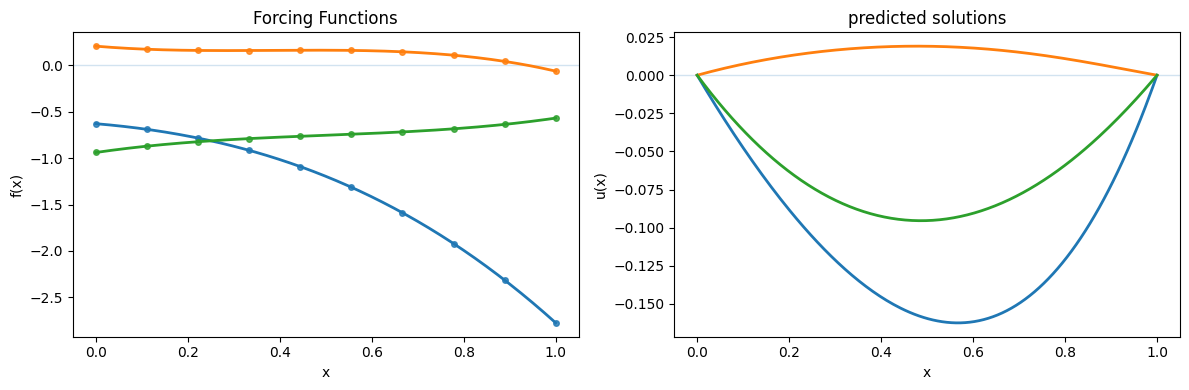

In [29]:
model.eval()
n_plot = 3

coeffs = sample_polynomial_coeffs(batch_size=n_plot, degree=3, scale=1.0)
f_sensor_vals = eval_polynomial(coeffs,x_sensors).squeeze(-1)

x_plot = torch.linspace(0,1,200,device="cuda").view(-1,1)

with torch.no_grad():
    u_pred = model(f_sensor_vals, x_plot)

u_pred = u_pred.squeeze(-1).cpu().numpy()
f_plot = eval_polynomial(coeffs,x_plot).squeeze(-1).cpu().numpy()

x_plot_np = x_plot.squeeze(-1).cpu().numpy()
x_sensors_np = x_sensors.squeeze(-1).cpu().numpy()
f_sensors_np = eval_polynomial(coeffs,x_sensors).squeeze(-1).cpu().numpy()


plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title("Forcing Functions")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.axhline(0,linewidth=1,alpha=0.2)

for i in range(n_plot):
    line, = plt.plot(x_plot_np,f_plot[i],linewidth=2)
    plt.plot(
        x_sensors_np,
        f_sensors_np[i],
        "o",
        markersize=4,
        color=line.get_color(),
        alpha=0.8,
    )

plt.subplot(1,2,2)
plt.title("predicted solutions")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.axhline(0, linewidth=1, alpha=0.2)

for i in range(n_plot):
    plt.plot(x_plot_np, u_pred[i], linewidth=2)

plt.tight_layout()
plt.show()    

## 8. Finite Difference Reference Solver

`solve_poisson_fd(x, f)` assembles and directly solves the standard second-order finite difference system for $-u'' = f$ with Dirichlet boundary conditions, providing a classical numerical ground-truth for validation.

In [30]:
def solve_poisson_fd(x,f):

    N = len(x)
    h = x[1] - x[0]
    n = N-2

    diag = (2.0 / h**2) * np.ones(n)
    off = (-1.0 / h**2) * np.ones(n - 1)

    A = np.diag(diag) + np.diag(off,k=1) + np.diag(off,k=-1)
    b = f[1:-1].copy()

    u_int = np.linalg.solve(A,b)

    u = np.zeros(N)
    u[1:-1] = u_int
    return u

## 9. Quantitative Evaluation

For 3 held-out test forcing functions, we compute:

| Metric | Description |
|---|---|
| **Residual $L^2$** | $\sqrt{\text{mean}((-u'' - f)^2)}$ — how well the PDE is satisfied |
| **Residual max** | $\max|{-u'' - f}|$ — worst-case pointwise PDE violation |
| **FDM relative $L^2$** | $\|u_{\text{pred}} - u_{\text{FD}}\| / \|u_{\text{FD}}\|$ — deviation from classical solver |

Low values in all three columns confirm that the network has genuinely learnt to solve the PDE.

In [31]:
model.eval()

n_test = 3

coeff_test =  sample_polynomial_coeffs(batch_size=n_test, degree=3, scale=1.0)

f_sensor_test = eval_polynomial(coeff_test,x_sensors).squeeze(-1)

N_dense = 400
x_dense = torch.linspace(0,1,N_dense,device="cuda").view(-1,1)

with torch.no_grad():
    u_pred = model(f_sensor_test,x_dense).squeeze(-1)

f_dense = eval_polynomial(coeff_test,x_dense).squeeze(-1)

x_in = x_dense.unsqueeze(0).repeat(n_test,1,1).clone().detach().requires_grad_(True)
u_for_res = model(f_sensor_test,x_in)
u_xx = second_derivative(u_for_res,x_in).squeeze(-1)
res = (-u_xx - f_dense).detach().cpu().numpy()

res_l2 = np.sqrt(np.mean(res**2,axis=1))
res_max = np.max(np.abs(res),axis=1)

x_np = x_dense.squeeze(-1).detach().cpu().numpy()
u_pred_np = u_pred.detach().cpu().numpy()
f_np = f_dense.detach().cpu().numpy()

rel_l2 = []
for i in range(n_test):
    u_fd = solve_poisson_fd(x_np,f_np[i])
    num = np.linalg.norm(u_pred_np[i] - u_fd)
    den = np.linalg.norm(u_fd) + 1e-12
    rel_l2.append(num / den)

for i in range(n_test):
    print(
        f"Test {i} residual L2 = {res_l2[i]:.3e}, residual max = {res_max[i]:.3e}," 
        f"FD relative L2 error = {rel_l2[i]:.3e}"
    )    

Test 0 residual L2 = 2.001e-02, residual max = 2.507e-02,FD relative L2 error = 3.789e-02
Test 1 residual L2 = 8.774e-03, residual max = 1.645e-02,FD relative L2 error = 5.066e-03
Test 2 residual L2 = 5.932e-03, residual max = 1.342e-02,FD relative L2 error = 9.938e-03


## 10. Comparison Plots: DeepONet vs Finite Differences

Each panel overlays the DeepONet prediction (dashed) against the FDM reference (solid) for one test forcing function, with the relative $L^2$ error and PDE residual $L^2$ annotated in the title.

> **Key result**: close agreement between the two curves, achieved with **zero labelled training data** — the network was trained only on the PDE constraint.

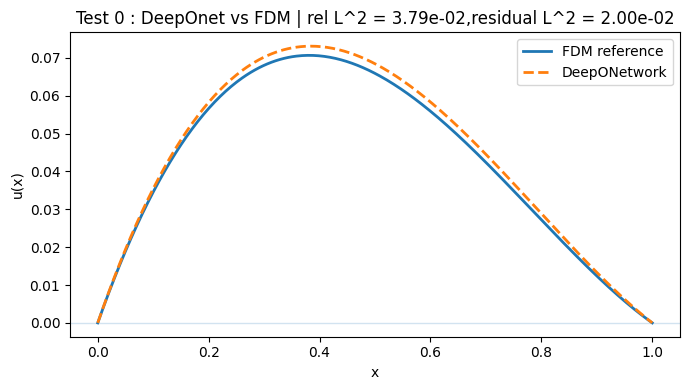

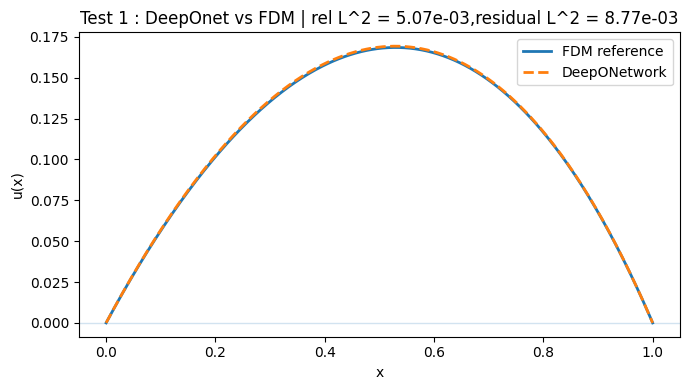

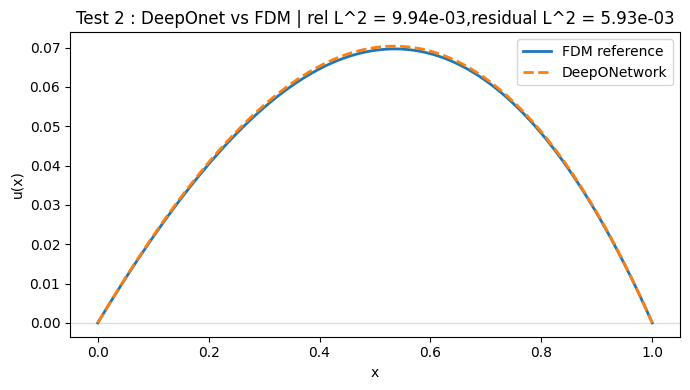

In [32]:
for i in range(n_test):

    u_fd = solve_poisson_fd(x_np , f_np[i])

    num = np.linalg.norm(u_pred_np[i] - u_fd)
    den = np.linalg.norm(u_fd) + 1e-12
    rel_err = float(num/den)

    res_err = float(res_l2[i])

    plt.figure(figsize=(7,4))
    plt.plot(x_np,u_fd,linewidth=2,label="FDM reference")
    plt.plot(x_np,u_pred_np[i],linewidth=2,linestyle="--",label="DeepONetwork")
    plt.axhline(0,linewidth=1,alpha=0.2)
    plt.title(
        f"Test {i} : DeepOnet vs FDM | "
        f"rel L^2 = {rel_err:.2e},residual L^2 = {res_err:.2e}"
    )
    plt.xlabel("x")
    plt.ylabel("u(x)")
    plt.legend()
    plt.tight_layout()
    plt.show()